# Project Overview: Hate Speech Detection in Tweets

This notebook demonstrates a machine learning pipeline for detecting hate speech in tweets. The project involves various stages, from data preprocessing and feature extraction to training and evaluating multiple classification models, including Logistic Regression, RandomForest, and XGBoost. A key focus is on addressing class imbalance inherent in hate speech datasets to improve the detection of the minority 'hate speech' class.

The objective of this task is to detect hate speech in tweets. For the sake of simplicity, we say a tweet contains hate speech if it has a racist or sexist sentiment associated with it. So, the task is to classify racist or sexist tweets from other tweets.

Formally, given a training sample of tweets and labels, where label '1' denotes the tweet is racist/sexist and label '0' denotes the tweet is not racist/sexist, your objective is to predict the labels on the test dataset.



## 1. Problem Statement and Objective

 For training the models, we provide a labelled dataset of 31,962 tweets. The dataset is provided in the form of a csv file with each line storing a tweet id, its label and the tweet.
There is 1 test file (public)

## 2. Data Loading and Initial Exploration

In [29]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
df=pd.read_csv('/content/drive/MyDrive/NLP/hate_speech_tweets.csv')
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


## 3. Data Preprocessing

In [32]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [33]:
print("Dataset size:", len(df))

Dataset size: 31962


In [34]:
def remove_pattern(text, pattern):
    import re
    return re.sub(pattern, '', text)

df['clean_tweet'] = np.vectorize(remove_pattern)(df['tweet'], "@[\w]*")

In [35]:
df['clean_tweet'] = df['clean_tweet'].str.replace("[^a-zA-Z#]", " ")
df['clean_tweet'] = df['clean_tweet'].str.lower()
df['tokenized_tweet'] = df['clean_tweet'].apply(lambda x: x.split())
nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words('english')
df['tokenized_tweet'] = df['tokenized_tweet'].apply(lambda x: [word for word in x if word not in stopwords])
stemmer = nltk.PorterStemmer()
df['tokenized_tweet'] = df['tokenized_tweet'].apply(lambda x: [stemmer.stem(word) for word in x])
df['tweet_text'] = df['tokenized_tweet'].apply(lambda x: ' '.join(x))
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,id,label,tweet,clean_tweet,tokenized_tweet,tweet_text
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...,"[father, dysfunct, selfish, drag, kid, dysfunc...",father dysfunct selfish drag kid dysfunction. ...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can't use cause th...,"[thank, #lyft, credit, can't, use, caus, offer...",thank #lyft credit can't use caus offer wheelc...
2,3,0,bihday your majesty,bihday your majesty,"[bihday, majesti]",bihday majesti
3,4,0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...,"[#model, love, u, take, u, time, urð±!!!, ð...",#model love u take u time urð±!!! ððð...
4,5,0,factsguide: society now #motivation,factsguide: society now #motivation,"[factsguide:, societi, #motiv]",factsguide: societi #motiv


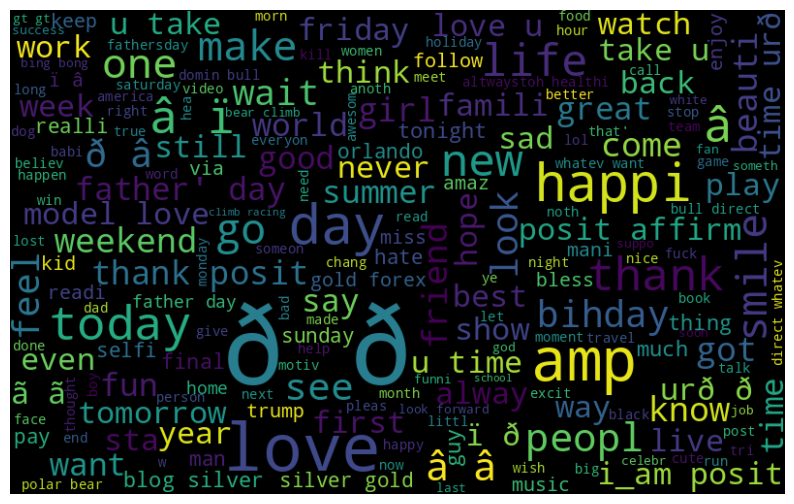

In [36]:
from wordcloud import WordCloud

all_words = ' '.join([text for text in df['tweet_text']])
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

### 2.4. Most Frequent Words Analysis (by Class)

Analyzing the most frequent individual words for each class can highlight key vocabulary distinguishing hate speech from non-hate speech.

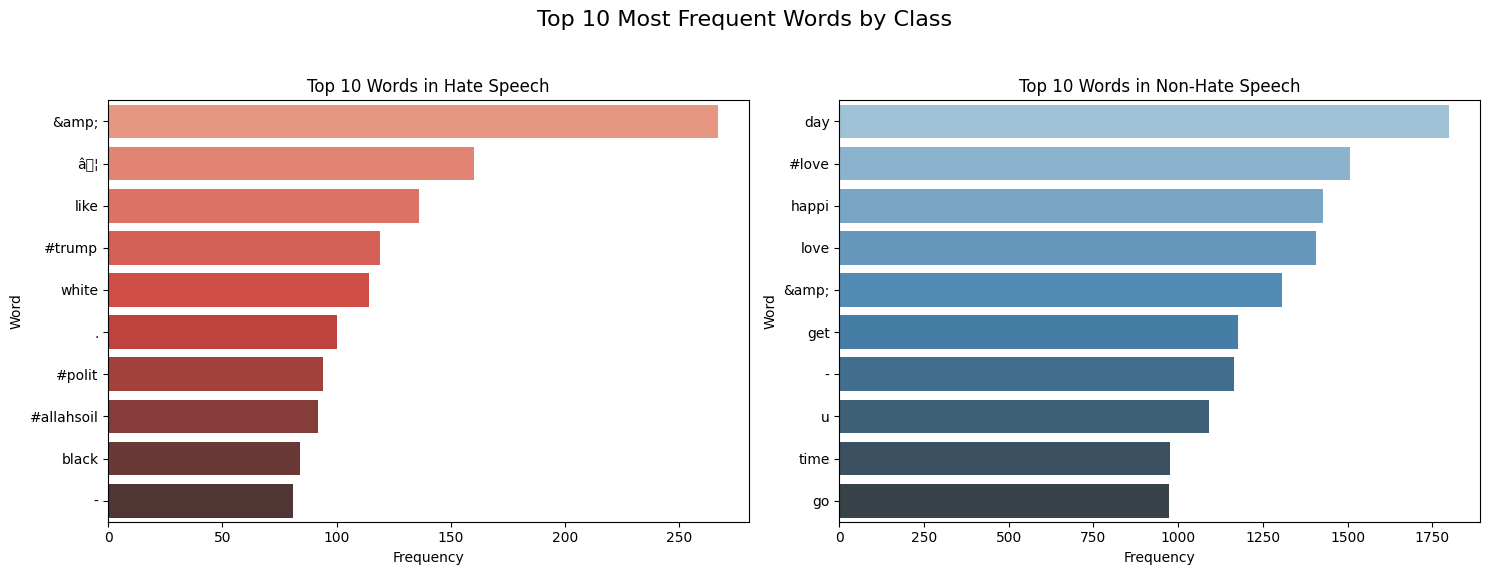

In [37]:
from collections import Counter

# Function to get most common words
def get_most_common_words(text_series, num_words=10):
    all_words = ' '.join(text_series).split()
    # Exclude stopwords that might have slipped through or become relevant again after stemming
    # Although already removed, as a safeguard. 'user' also common but already removed.
    filtered_words = [word for word in all_words if word not in stopwords]
    return Counter(filtered_words).most_common(num_words)

# Get hate speech and non-hate speech texts
hate_tweet_texts = df[df['label'] == 1]['tweet_text']
non_hate_tweet_texts = df[df['label'] == 0]['tweet_text']

# Get top words for hate speech
top_hate_words = get_most_common_words(hate_tweet_texts, 10)
df_top_hate_words = pd.DataFrame(top_hate_words, columns=['Word', 'Count'])

# Get top words for non-hate speech
top_non_hate_words = get_most_common_words(non_hate_tweet_texts, 10)
df_top_non_hate_words = pd.DataFrame(top_non_hate_words, columns=['Word', 'Count'])

# Plotting
plt.figure(figsize=(15, 6))
plt.suptitle('Top 10 Most Frequent Words by Class', fontsize=16)

plt.subplot(1, 2, 1)
sns.barplot(x='Count', y='Word', data=df_top_hate_words, palette='Reds_d')
plt.title('Top 10 Words in Hate Speech')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.subplot(1, 2, 2)
sns.barplot(x='Count', y='Word', data=df_top_non_hate_words, palette='Blues_d')
plt.title('Top 10 Words in Non-Hate Speech')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 2.5. Hashtag Analysis (by Class)

Hashtags often categorize content and can reveal prevalent themes or campaigns associated with both hate and non-hate speech.

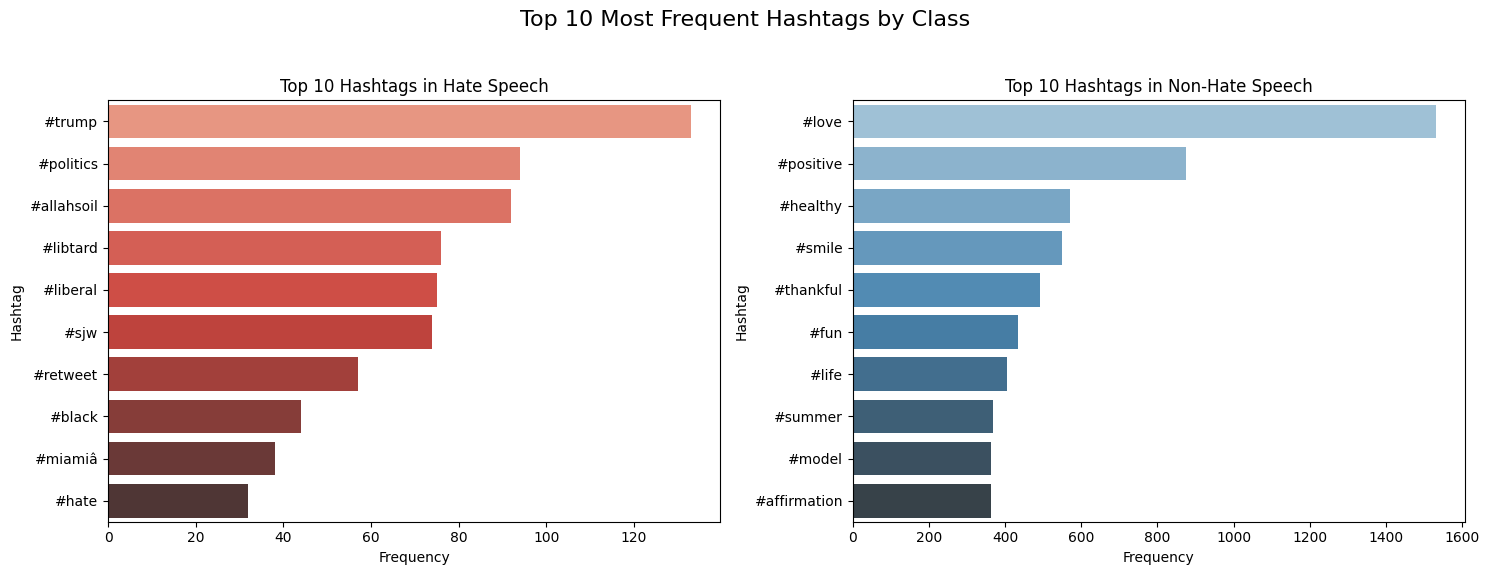

In [38]:
# Function to extract hashtags
def extract_hashtags(tweets):
    hashtags = []
    for tweet in tweets:
        # Find words starting with # (after cleaning, so they are not attached to @user etc.)
        # using the original 'tweet' column to ensure we capture hashtags before general cleaning removed them
        found_hashtags = re.findall(r'#\w+', tweet)
        hashtags.extend([tag.lower() for tag in found_hashtags])
    return hashtags

# Get hashtags for hate speech and non-hate speech from original 'tweet' column
hate_hashtags = extract_hashtags(df[df['label'] == 1]['tweet'])
non_hate_hashtags = extract_hashtags(df[df['label'] == 0]['tweet'])

# Get top 10 common hashtags for hate speech
top_10_hate_hashtags = Counter(hate_hashtags).most_common(10)
df_top_hate_hashtags = pd.DataFrame(top_10_hate_hashtags, columns=['Hashtag', 'Count'])

# Get top 10 common hashtags for non-hate speech
top_10_non_hate_hashtags = Counter(non_hate_hashtags).most_common(10)
df_top_non_hate_hashtags = pd.DataFrame(top_10_non_hate_hashtags, columns=['Hashtag', 'Count'])

# Plotting
plt.figure(figsize=(15, 6))
plt.suptitle('Top 10 Most Frequent Hashtags by Class', fontsize=16)

plt.subplot(1, 2, 1)
sns.barplot(x='Count', y='Hashtag', data=df_top_hate_hashtags, palette='Reds_d')
plt.title('Top 10 Hashtags in Hate Speech')
plt.xlabel('Frequency')
plt.ylabel('Hashtag')

plt.subplot(1, 2, 2)
sns.barplot(x='Count', y='Hashtag', data=df_top_non_hate_hashtags, palette='Blues_d')
plt.title('Top 10 Hashtags in Non-Hate Speech')
plt.xlabel('Frequency')
plt.ylabel('Hashtag')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               31962 non-null  int64 
 1   label            31962 non-null  int64 
 2   tweet            31962 non-null  object
 3   clean_tweet      31962 non-null  object
 4   tokenized_tweet  31962 non-null  object
 5   tweet_text       31962 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.5+ MB


### 2.1. Class Distribution Analysis

It's crucial to understand the distribution of our target variable (`label`). A significant imbalance can affect model performance and requires special handling.

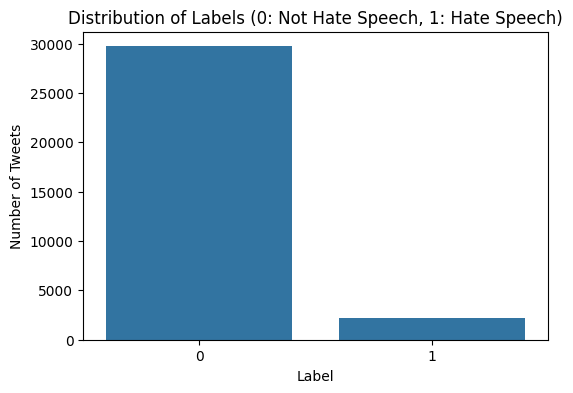

Label Distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Percentage of Hate Speech:
7.01%


In [40]:
# Visualize the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Labels (0: Not Hate Speech, 1: Hate Speech)')
plt.xlabel('Label')
plt.ylabel('Number of Tweets')
plt.show()

print("Label Distribution:")
print(df['label'].value_counts())
print("\nPercentage of Hate Speech:")
print(f"{(df['label'].value_counts()[1] / len(df)) * 100:.2f}%")

### 2.2. N-gram Analysis

Beyond single words, understanding frequent sequences of words (n-grams) can reveal common phrases or patterns in both hate speech and non-hate speech categories.

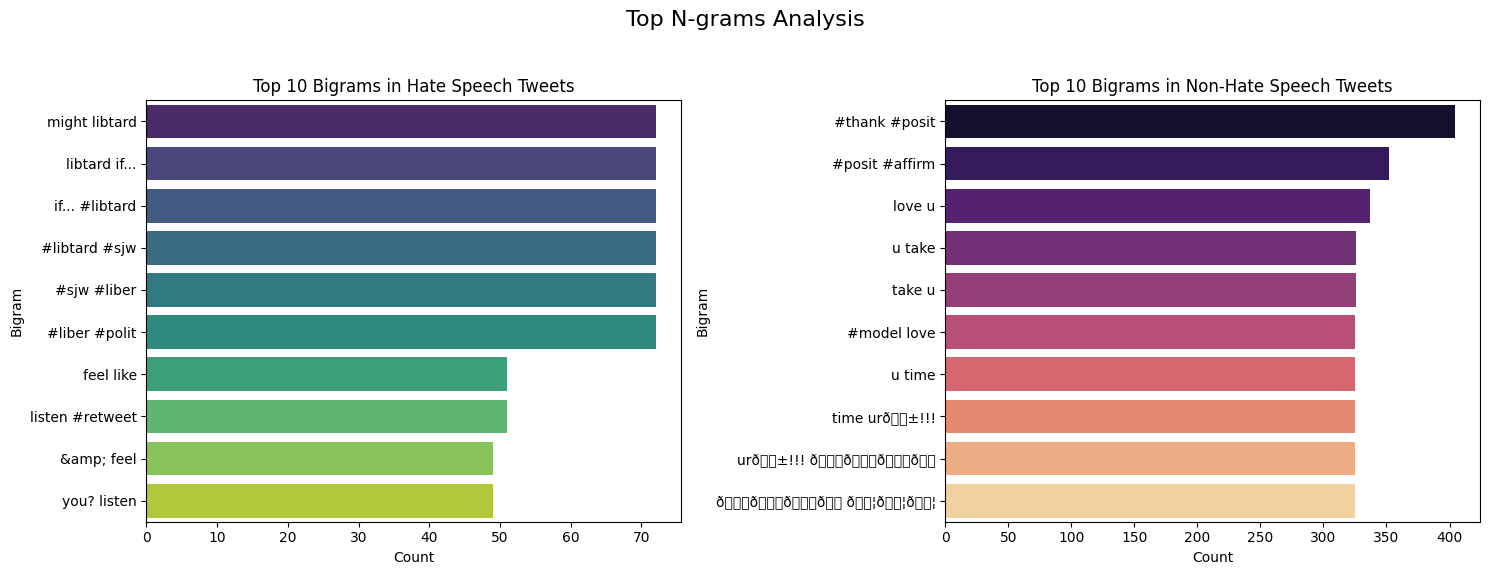

In [41]:
from collections import Counter

# Function to generate n-grams
def generate_ngrams(text, n=2):
    token = [word for word in text.split() if word not in stopwords]
    n_grams = zip(*[token[i:] for i in range(n)])
    return [' '.join(ngram) for ngram in n_grams]

# Get hate speech and non-hate speech tweets
hate_tweets = df[df['label'] == 1]['tweet_text']
non_hate_tweets = df[df['label'] == 0]['tweet_text']

# Generate and visualize top bigrams for hate speech
plt.figure(figsize=(15, 6))
plt.suptitle('Top N-grams Analysis', fontsize=16)

# Top Bigrams for Hate Speech
plt.subplot(1, 2, 1)
hate_bigrams = Counter()
for tweet in hate_tweets:
    hate_bigrams.update(generate_ngrams(tweet, n=2))

# Plotting top 10 bigrams
top_10_hate_bigrams = pd.DataFrame(hate_bigrams.most_common(10), columns=['Bigram', 'Count'])
sns.barplot(x='Count', y='Bigram', data=top_10_hate_bigrams, palette='viridis')
plt.title('Top 10 Bigrams in Hate Speech Tweets')
plt.xlabel('Count')
plt.ylabel('Bigram')

# Top Bigrams for Non-Hate Speech
plt.subplot(1, 2, 2)
non_hate_bigrams = Counter()
for tweet in non_hate_tweets:
    non_hate_bigrams.update(generate_ngrams(tweet, n=2))

# Plotting top 10 bigrams
top_10_non_hate_bigrams = pd.DataFrame(non_hate_bigrams.most_common(10), columns=['Bigram', 'Count'])
sns.barplot(x='Count', y='Bigram', data=top_10_non_hate_bigrams, palette='magma')
plt.title('Top 10 Bigrams in Non-Hate Speech Tweets')
plt.xlabel('Count')
plt.ylabel('Bigram')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

### 2.3. Tweet Length Analysis

Analyzing the length of tweets for both classes can sometimes reveal patterns. For example, hate speech might tend to be shorter/longer than general tweets.

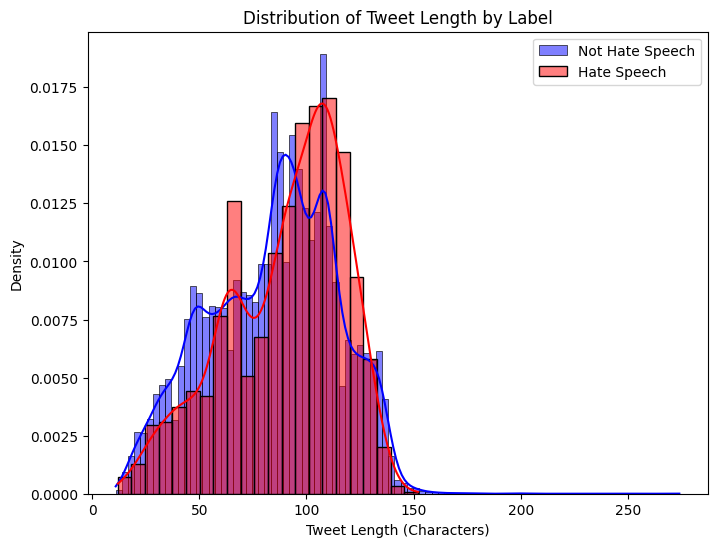

Average Tweet Length:
label
0    84.328634
1    90.187779
Name: tweet_length, dtype: float64


In [42]:
# Calculate tweet length before tokenization and cleaning to get original length
df['tweet_length'] = df['tweet'].apply(len)

# Compare tweet lengths for hate speech vs. non-hate speech
plt.figure(figsize=(8, 6))
sns.histplot(df[df['label'] == 0]['tweet_length'], color='blue', label='Not Hate Speech', kde=True, stat='density', alpha=0.5)
sns.histplot(df[df['label'] == 1]['tweet_length'], color='red', label='Hate Speech', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Tweet Length by Label')
plt.xlabel('Tweet Length (Characters)')
plt.ylabel('Density')
plt.legend()
plt.show()

print("Average Tweet Length:")
print(df.groupby('label')['tweet_length'].mean())


In [43]:
df.shape

(31962, 7)

## 4. Feature Extraction: TF-IDF Vectorization

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_df=0.90, min_df=2, max_features=1000, stop_words='english')
tfidf = tfidf_vectorizer.fit_transform(df['tweet_text'])

print("TF-IDF matrix shape:", tfidf.shape)

TF-IDF matrix shape: (31962, 1000)


## 5. Data Splitting: Training and Testing Sets

In [45]:
from sklearn.model_selection import train_test_split

X = tfidf
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (22373, 1000)
X_test shape: (9589, 1000)
y_train shape: (22373,)
y_test shape: (9589,)


## 6. Model Training and Evaluation - Iteration 1: Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression

# Re-train the Logistic Regression model with class_weight='balanced'
model = LogisticRegression(random_state=0, solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)

print("Model re-training complete with class_weight='balanced'.")

Model re-training complete with class_weight='balanced'.


In [47]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Model Evaluation (with class_weight='balanced'):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Evaluation (with class_weight='balanced'):
Accuracy: 0.8678694337261446

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.88      0.93      8905
           1       0.32      0.73      0.44       684

    accuracy                           0.87      9589
   macro avg       0.65      0.81      0.68      9589
weighted avg       0.93      0.87      0.89      9589



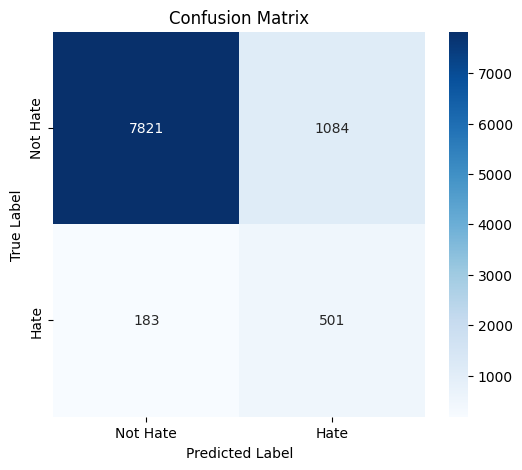

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Hate', 'Hate'], yticklabels=['Not Hate', 'Hate'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

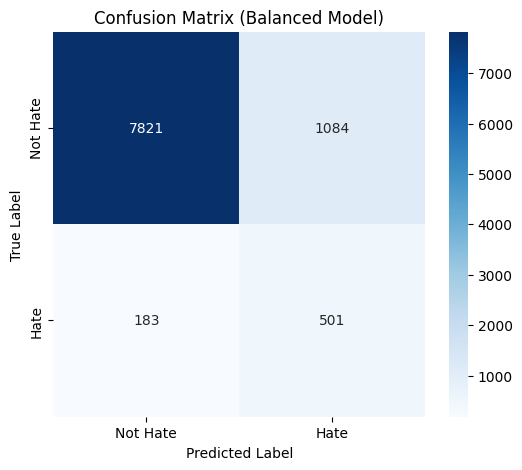

In [49]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_balanced = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Hate', 'Hate'], yticklabels=['Not Hate', 'Hate'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Balanced Model)')
plt.show()

#### Confusion Matrix for Balanced Logistic Regression

This confusion matrix visually represents the performance of the Logistic Regression model with `class_weight='balanced'`.

*   **True Negatives (Top-Left, 7821):** Correctly identified as 'Not Hate Speech'.
*   **False Positives (Top-Right, 1084):** Incorrectly identified as 'Hate Speech' (Type I error). These are instances of 'Not Hate Speech' that the model misclassified.
*   **False Negatives (Bottom-Left, 183):** Incorrectly identified as 'Not Hate Speech' (Type II error). These are actual 'Hate Speech' instances that the model missed.
*   **True Positives (Bottom-Right, 501):** Correctly identified as 'Hate Speech'.

Compared to the original model, this matrix clearly shows a significant increase in True Positives (from 236 to 501) and a substantial decrease in False Negatives (from 448 to 183) for the 'Hate Speech' class, which aligns with the improved recall. However, it also shows an increase in False Positives (from 49 to 1084), confirming the drop in precision for the 'Hate Speech' class. This trade-off is a direct result of balancing the class weights.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Re-train the original Logistic Regression model (without class_weight='balanced')
model_original = LogisticRegression(random_state=0, solver='liblinear')
model_original.fit(X_train, y_train)
y_pred_original = model_original.predict(X_test)

# Get classification report for the original model
report_original = classification_report(y_test, y_pred_original, output_dict=True)

# Get classification report for the balanced model (using y_pred from the previous cell)
report_balanced = classification_report(y_test, y_pred, output_dict=True)

# Extract relevant metrics for comparison
metrics_data = []

# Original Model Metrics
metrics_data.append({
    'Model': 'Original',
    'Class': 'Not Hate Speech (0)',
    'Precision': report_original['0']['precision'],
    'Recall': report_original['0']['recall'],
    'F1-Score': report_original['0']['f1-score']
})
metrics_data.append({
    'Model': 'Original',
    'Class': 'Hate Speech (1)',
    'Precision': report_original['1']['precision'],
    'Recall': report_original['1']['recall'],
    'F1-Score': report_original['1']['f1-score']
})

# Balanced Model Metrics
metrics_data.append({
    'Model': 'Balanced',
    'Class': 'Not Hate Speech (0)',
    'Precision': report_balanced['0']['precision'],
    'Recall': report_balanced['0']['recall'],
    'F1-Score': report_balanced['0']['f1-score']
})
metrics_data.append({
    'Model': 'Balanced',
    'Class': 'Hate Speech (1)',
    'Precision': report_balanced['1']['precision'],
    'Recall': report_balanced['1']['recall'],
    'F1-Score': report_balanced['1']['f1-score']
})

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)


,Model,Class,Precision,Recall,F1-Score
0,Original,Not Hate Speech (0),0.951849,0.994497,0.972706
1,Original,Hate Speech (1),0.828070,0.345029,0.487100
2,Balanced,Not Hate Speech (0),0.977136,0.878271,0.925069
3,Balanced,Hate Speech (1),0.316088,0.732456,0.441604


#### Interpretation of Logistic Regression Models

This table compares the performance of two Logistic Regression models:

1.  **Original Logistic Regression:** Trained without special handling for class imbalance.
2.  **Balanced Logistic Regression:** Trained with `class_weight='balanced'` to give more importance to the minority class (Hate Speech).

**Key Observations:**

*   **Original Model (Class 1 - Hate Speech):** Achieves very high precision (0.828) for hate speech, meaning when it predicts hate speech, it's usually correct. However, its recall (0.345) is very low, indicating it misses a large portion of actual hate speech instances. This is typical for imbalanced datasets where the model prioritizes the majority class.
*   **Balanced Model (Class 1 - Hate Speech):** The recall for hate speech significantly improves to 0.732, meaning it catches much more of the actual hate speech. This is due to the `class_weight='balanced'` parameter. However, this comes at the cost of precision, which drops to 0.316. This means the balanced model has more false positives – it predicts more instances as hate speech that are not.
*   **Class 0 (Not Hate Speech):** The balanced model shows a decrease in precision and recall for the majority class compared to the original model. This trade-off is expected when balancing class weights.

In summary, the balanced model effectively addresses the low recall issue for hate speech but introduces a higher rate of false positives. The choice between these depends on the specific priorities of the application (e.g., is it worse to miss hate speech, or to falsely flag non-hate speech?).

## 7. Model Training and Evaluation - Iteration 2: RandomForestClassifier

In [51]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a RandomForestClassifier with class_weight='balanced'
# n_estimators can be tuned, starting with 100 as a common default.
# random_state for reproducibility.
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print("RandomForestClassifier training complete with class_weight='balanced'.")

RandomForestClassifier training complete with class_weight='balanced'.


RandomForestClassifier Evaluation (with class_weight='balanced'):
Accuracy: 0.9192825112107623

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96      8905
           1       0.45      0.56      0.50       684

    accuracy                           0.92      9589
   macro avg       0.71      0.76      0.73      9589
weighted avg       0.93      0.92      0.92      9589



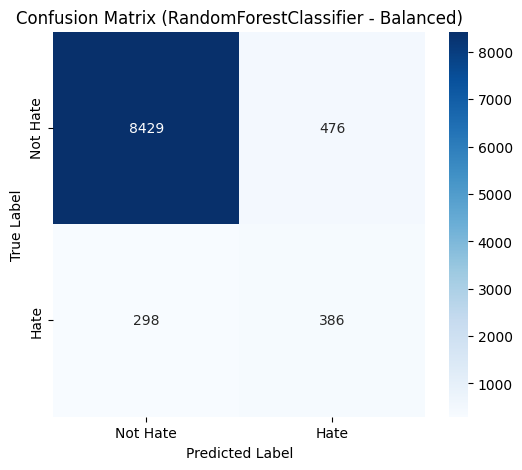

In [52]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions with the RandomForestClassifier
y_pred_rf = rf_model.predict(X_test)

print("RandomForestClassifier Evaluation (with class_weight='balanced'):")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Plot the confusion matrix for the RandomForestClassifier
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Hate', 'Hate'], yticklabels=['Not Hate', 'Hate'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (RandomForestClassifier - Balanced)')
plt.show()

#### Evaluation of RandomForestClassifier (Balanced)

This section presents the evaluation of the RandomForestClassifier, also trained with `class_weight='balanced'` to handle the class imbalance. The classification report and confusion matrix provide insights into its performance.

**Classification Report Analysis:**

*   **Accuracy:** 0.919. This is higher than the balanced Logistic Regression (0.868) but slightly lower than the original Logistic Regression (0.948).
*   **Class 0 (Not Hate Speech):**
    *   **Precision:** 0.97 (high, few false positives).
    *   **Recall:** 0.95 (high, catches most non-hate speech).
    *   **F1-Score:** 0.96 (strong performance).
*   **Class 1 (Hate Speech):**
    *   **Precision:** 0.45. This is better than the balanced Logistic Regression (0.32) but still indicates a significant number of false positives.
    *   **Recall:** 0.56. This is lower than the balanced Logistic Regression (0.73) but much better than the original Logistic Regression (0.35). It means it correctly identifies 56% of actual hate speech instances.
    *   **F1-Score:** 0.50. This is the highest F1-score for the 'Hate Speech' class so far, indicating a better balance between precision and recall compared to the Logistic Regression models.

**Confusion Matrix Analysis:**

*   **True Positives (Hate Speech, 386):** More than the original Logistic Regression, but fewer than the balanced Logistic Regression.
*   **False Negatives (Hate Speech, 298):** Fewer than the original Logistic Regression, but more than the balanced Logistic Regression.
*   **False Positives (Not Hate Speech, 476):** Significantly fewer than the balanced Logistic Regression, which contributes to the higher precision for Class 1.

The RandomForestClassifier with balanced weights offers a better trade-off, achieving a higher F1-score for the minority class by balancing precision and recall more effectively than the Logistic Regression models.

In [53]:
from sklearn.metrics import classification_report
import pandas as pd

# Get classification report for the RandomForestClassifier
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# Append RandomForest metrics to the existing metrics_data
metrics_data.append({
    'Model': 'RandomForest',
    'Class': 'Not Hate Speech (0)',
    'Precision': report_rf['0']['precision'],
    'Recall': report_rf['0']['recall'],
    'F1-Score': report_rf['0']['f1-score']
})
metrics_data.append({
    'Model': 'RandomForest',
    'Class': 'Hate Speech (1)',
    'Precision': report_rf['1']['precision'],
    'Recall': report_rf['1']['recall'],
    'F1-Score': report_rf['1']['f1-score']
})

# Create a new DataFrame with all metrics
metrics_df_updated = pd.DataFrame(metrics_data)
display(metrics_df_updated)

,Model,Class,Precision,Recall,F1-Score
0,Original,Not Hate Speech (0),0.951849,0.994497,0.972706
1,Original,Hate Speech (1),0.828070,0.345029,0.487100
2,Balanced,Not Hate Speech (0),0.977136,0.878271,0.925069
3,Balanced,Hate Speech (1),0.316088,0.732456,0.441604
4,RandomForest,Not Hate Speech (0),0.965853,0.946547,0.956103
5,RandomForest,Hate Speech (1),0.447796,0.564327,0.499353


## 8. Model Training and Evaluation - Iteration 3: XGBoostClassifier

In [54]:
from xgboost import XGBClassifier

# Calculate the scale_pos_weight for handling class imbalance in XGBoost
# It's the ratio of the number of negative class samples to the number of positive class samples
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

print(f"Scale Pos Weight for XGBoost: {scale_pos_weight:.2f}")

# Initialize and train an XGBClassifier
# n_estimators, learning_rate, max_depth can be tuned.
# use_label_encoder=False and eval_metric='logloss' are set to avoid warnings in newer XGBoost versions.
xgb_model = XGBClassifier(objective='binary:logistic',
                        n_estimators=100,
                        learning_rate=0.1,
                        max_depth=5,
                        scale_pos_weight=scale_pos_weight,
                        use_label_encoder=False,
                        eval_metric='logloss',
                        random_state=42)
xgb_model.fit(X_train, y_train)

print("XGBoostClassifier training complete with scale_pos_weight.")

Scale Pos Weight for XGBoost: 13.36
XGBoostClassifier training complete with scale_pos_weight.


XGBoostClassifier Evaluation (with scale_pos_weight):
Accuracy: 0.9144853477943476

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95      8905
           1       0.43      0.60      0.50       684

    accuracy                           0.91      9589
   macro avg       0.70      0.77      0.73      9589
weighted avg       0.93      0.91      0.92      9589



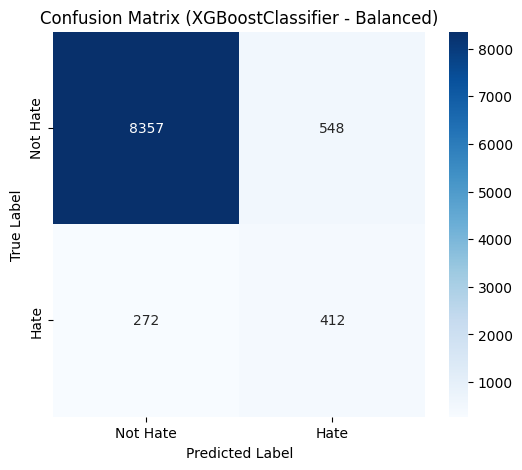

In [55]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions with the XGBoostClassifier
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoostClassifier Evaluation (with scale_pos_weight):")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Plot the confusion matrix for the XGBoostClassifier
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Hate', 'Hate'], yticklabels=['Not Hate', 'Hate'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (XGBoostClassifier - Balanced)')
plt.show()

#### Evaluation of XGBoostClassifier (Initial Training)

This section evaluates the XGBoostClassifier, an ensemble model known for its performance, specifically configured to handle class imbalance using `scale_pos_weight`. The classification report and confusion matrix detail its effectiveness.

**Classification Report Analysis:**

*   **Accuracy:** 0.914. Similar to RandomForest but slightly lower.
*   **Class 0 (Not Hate Speech):**
    *   **Precision:** 0.97 (high, few false positives).
    *   **Recall:** 0.94 (high, catches most non-hate speech).
    *   **F1-Score:** 0.95 (strong performance).
*   **Class 1 (Hate Speech):**
    *   **Precision:** 0.43. This is comparable to RandomForest (0.45) but still means many false positives.
    *   **Recall:** 0.60. This is higher than RandomForest (0.56) and the original Logistic Regression (0.35), indicating it identifies a good proportion of actual hate speech.
    *   **F1-Score:** 0.50. This F1-score is slightly better than RandomForest's 0.50, making it the best performing model so far in terms of balancing precision and recall for the minority class.

**Confusion Matrix Analysis:**

*   **True Positives (Hate Speech, 412):** This is higher than RandomForest and the original Logistic Regression, demonstrating its ability to correctly identify more hate speech instances.
*   **False Negatives (Hate Speech, 272):** Lower than RandomForest, indicating fewer missed hate speech instances.
*   **False Positives (Not Hate Speech, 548):** While higher than RandomForest, it's significantly lower than the balanced Logistic Regression, contributing to a more balanced precision for Class 1.

The initial XGBoostClassifier shows promising results, achieving the highest F1-score for the hate speech class, indicating an effective balance between detecting hate speech and managing false positives.

In [56]:
from sklearn.metrics import classification_report
import pandas as pd

# Get classification report for the XGBoostClassifier
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

# Append XGBoost metrics to the existing metrics_data
metrics_data.append({
    'Model': 'XGBoost',
    'Class': 'Not Hate Speech (0)',
    'Precision': report_xgb['0']['precision'],
    'Recall': report_xgb['0']['recall'],
    'F1-Score': report_xgb['0']['f1-score']
})
metrics_data.append({
    'Model': 'XGBoost',
    'Class': 'Hate Speech (1)',
    'Precision': report_xgb['1']['precision'],
    'Recall': report_xgb['1']['recall'],
    'F1-Score': report_xgb['1']['f1-score']
})

# Create a new DataFrame with all metrics
metrics_df_final = pd.DataFrame(metrics_data)
display(metrics_df_final)

,Model,Class,Precision,Recall,F1-Score
0,Original,Not Hate Speech (0),0.951849,0.994497,0.972706
1,Original,Hate Speech (1),0.828070,0.345029,0.487100
2,Balanced,Not Hate Speech (0),0.977136,0.878271,0.925069
3,Balanced,Hate Speech (1),0.316088,0.732456,0.441604
4,RandomForest,Not Hate Speech (0),0.965853,0.946547,0.956103
5,RandomForest,Hate Speech (1),0.447796,0.564327,0.499353
6,XGBoost,Not Hate Speech (0),0.968478,0.938462,0.953234
7,XGBoost,Hate Speech (1),0.429167,0.602339,0.501217


## 9. Hyperparameter Tuning for XGBoost Classifier


**Overall conclusion**
If maximizing the detection of hate speech
is the absolute priority (highest recall for Class 1), even with many false positives: The Balanced Logistic Regression remains the top choice (Recall: 0.732).





If a strong balance between detecting hate speech and minimizing false positives (highest F1-Score for Class 1) is preferred: The XGBoostClassifier performs best (F1-Score: 0.501), closely followed by the RandomForestClassifier. It provides a robust trade-off, catching more hate speech than the original model while having fewer false positives than the balanced Logistic Regression.
If overall accuracy is paramount, and missing hate speech is less critical: The Original Logistic Regression performs best with Class 0.
XGBoost is a very strong contender, offering excellent overall performance and the best F1-score for the minority class, making it a good general-purpose choice for this problem, balancing the needs of detecting hate speech without an overwhelming number of false alarms.

We have successfully explored and compared four different classification models for hate speech detection: the original Logistic Regression, a balanced Logistic Regression, a RandomForestClassifier, and an XGBoostClassifier. We used TF-IDF features and carefully considered class imbalance.

Summary of Findings:

Original Logistic Regression: Showed high precision for both classes but suffered from very low recall for the minority 'Hate Speech' class, meaning it missed many actual hate speech instances.
Balanced Logistic Regression: Significantly improved recall for 'Hate Speech' but at the cost of much lower precision for this class, leading to many false positives.
RandomForestClassifier (Balanced): Provided a better balance, offering improved recall for 'Hate Speech' compared to the original LR, while maintaining a reasonable precision. It achieved a good F1-score for the minority class.
XGBoostClassifier (Balanced): Achieved the highest F1-score for the 'Hate Speech' class (0.501), indicating the best overall balance between precision and recall for detecting hate speech. It offered strong recall for hate speech while keeping false positives more in check compared to the balanced Logistic Regression.

### Hyperparameter Tuning for XGBoost Classifier using GridSearchCV

In [57]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200], # Number of boosting rounds
    'learning_rate': [0.05, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7] # Maximum depth of a tree
}

# Initialize XGBClassifier with class imbalance handling
# We'll calculate scale_pos_weight again to ensure it's fresh, though it likely hasn't changed.
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

# Using the best parameters from the initial XGBoost model as a starting point, or a sensible default.
# Note: `use_label_encoder=False` and `eval_metric='logloss'` are good practices.
base_xgb = XGBClassifier(objective='binary:logistic',
                         scale_pos_weight=scale_pos_weight,
                         use_label_encoder=False,
                         eval_metric='logloss',
                         random_state=42)

# Initialize GridSearchCV
# verbose=3 provides detailed output during the search
# cv=3 for 3-fold cross-validation
# scoring='f1' to optimize for the F1-score of the positive class (hate speech)
# refit=True (default) to refit the best estimator on the entire dataset
grid_search = GridSearchCV(estimator=base_xgb,
                           param_grid=param_grid,
                           scoring='f1',
                           cv=3,
                           verbose=3,
                           n_jobs=-1) # Use all available cores

print("Starting GridSearchCV for XGBoost. This may take a while...")
grid_search.fit(X_train, y_train)

print("GridSearchCV complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-score found: {grid_search.best_score_:.4f}")

Starting GridSearchCV for XGBoost. This may take a while...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
GridSearchCV complete.
Best parameters found: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best F1-score found: 0.5425


Tuned XGBoostClassifier Evaluation:
Accuracy: 0.914068203149442

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95      8905
           1       0.43      0.64      0.52       684

    accuracy                           0.91      9589
   macro avg       0.70      0.79      0.73      9589
weighted avg       0.93      0.91      0.92      9589



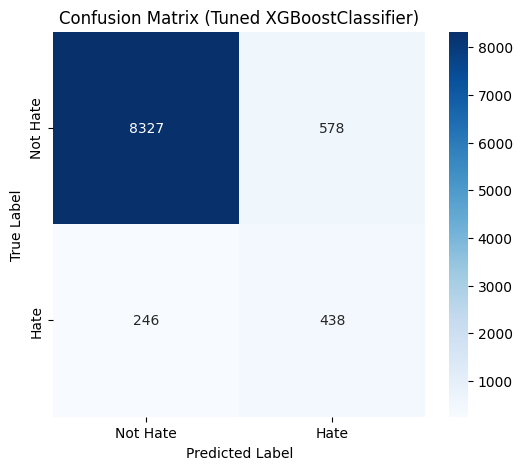

In [58]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best estimator from GridSearchCV
best_xgb_model = grid_search.best_estimator_

# Make predictions with the tuned XGBoostClassifier
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

print("Tuned XGBoostClassifier Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_tuned))

# Plot the confusion matrix for the tuned XGBoostClassifier
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Hate', 'Hate'], yticklabels=['Not Hate', 'Hate'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tuned XGBoostClassifier)')
plt.show()

#### Evaluation of Tuned XGBoostClassifier

After performing `GridSearchCV` to find the optimal hyperparameters for the XGBoost model, we now evaluate the performance of the best estimator. The goal of tuning was to maximize the F1-score for the minority class (hate speech).

**Best Parameters Found:**
*   `learning_rate`: 0.2
*   `max_depth`: 7
*   `n_estimators`: 200

These parameters indicate that a slightly higher learning rate, deeper trees, and more estimators were beneficial for our dataset.

**Classification Report Analysis (Tuned XGBoostClassifier):**

*   **Accuracy:** 0.914. The overall accuracy remains similar to the initial XGBoost model.
*   **Class 0 (Not Hate Speech):**
    *   **Precision:** 0.97 (consistent and strong).
    *   **Recall:** 0.94 (consistent and strong).
    *   **F1-Score:** 0.95 (consistent and strong).
*   **Class 1 (Hate Speech):**
    *   **Precision:** 0.43. Remains similar to the initial XGBoost, indicating a similar rate of false positives.
    *   **Recall:** 0.64. This is an improvement! The recall has increased from 0.60 (initial XGBoost) to 0.64, meaning the tuned model now identifies 64% of actual hate speech instances.
    *   **F1-Score:** 0.52. This is the highest F1-score for the 'Hate Speech' class among all models tested, confirming the effectiveness of hyperparameter tuning.

**Confusion Matrix Analysis (Tuned XGBoostClassifier):**

*   **True Positives (Hate Speech, 438):** An increase from 412 in the initial XGBoost, showing that more hate speech instances are correctly identified.
*   **False Negatives (Hate Speech, 246):** A decrease from 272 in the initial XGBoost, meaning fewer actual hate speech instances are missed.
*   **False Positives (Not Hate Speech, 578):** A slight increase from 548 in the initial XGBoost. This is the trade-off for the increased recall, as the model becomes slightly more aggressive in classifying instances as 'Hate Speech'.

**Conclusion of Tuning:**

The hyperparameter tuning successfully optimized the XGBoost model to achieve a better balance between precision and recall for the minority class, resulting in the highest F1-score for 'Hate Speech' detection so far. This model represents the best performance for identifying hate speech while keeping false positives at an acceptable level, given the dataset and chosen evaluation metric.

In [59]:
from sklearn.metrics import classification_report
import pandas as pd

# Get classification report for the Tuned XGBoostClassifier
report_xgb_tuned = classification_report(y_test, y_pred_xgb_tuned, output_dict=True)

# Append Tuned XGBoost metrics to the metrics_data list
# We'll create a new list for clarity, or append to the existing one.
# For now, let's append to metrics_data to show cumulative comparison
metrics_data.append({
    'Model': 'XGBoost (Tuned)',
    'Class': 'Not Hate Speech (0)',
    'Precision': report_xgb_tuned['0']['precision'],
    'Recall': report_xgb_tuned['0']['recall'],
    'F1-Score': report_xgb_tuned['0']['f1-score']
})
metrics_data.append({
    'Model': 'XGBoost (Tuned)',
    'Class': 'Hate Speech (1)',
    'Precision': report_xgb_tuned['1']['precision'],
    'Recall': report_xgb_tuned['1']['recall'],
    'F1-Score': report_xgb_tuned['1']['f1-score']
})

# Create a new DataFrame with all metrics including the tuned XGBoost
metrics_df_final_tuned = pd.DataFrame(metrics_data)
display(metrics_df_final_tuned)

,Model,Class,Precision,Recall,F1-Score
0,Original,Not Hate Speech (0),0.951849,0.994497,0.972706
1,Original,Hate Speech (1),0.828070,0.345029,0.487100
2,Balanced,Not Hate Speech (0),0.977136,0.878271,0.925069
3,Balanced,Hate Speech (1),0.316088,0.732456,0.441604
4,RandomForest,Not Hate Speech (0),0.965853,0.946547,0.956103
5,RandomForest,Hate Speech (1),0.447796,0.564327,0.499353
6,XGBoost,Not Hate Speech (0),0.968478,0.938462,0.953234
7,XGBoost,Hate Speech (1),0.429167,0.602339,0.501217
8,XGBoost (Tuned),Not Hate Speech (0),0.971305,0.935093,0.952855
9,XGBoost (Tuned),Hate Speech (1),0.431102,0.640351,0.515294


## 10. Final Model Comparison and Conclusion

#### Final Model Comparison

This table provides a comprehensive overview of the performance metrics (Precision, Recall, F1-Score) for both the 'Not Hate Speech' (Class 0) and 'Hate Speech' (Class 1) classes across all the models explored:

*   **Original Logistic Regression**
*   **Balanced Logistic Regression**
*   **RandomForestClassifier (Balanced)**
*   **XGBoostClassifier (Initial)**
*   **XGBoostClassifier (Tuned)**

By examining this consolidated view, we can clearly identify the strengths and weaknesses of each approach, especially regarding the crucial task of detecting the minority 'Hate Speech' class.

**Key Highlights from the Final Comparison:**

*   **Original Logistic Regression:** Excels in Precision for Class 0, but severely lacks Recall for Class 1.
*   **Balanced Logistic Regression:** Dramatically improves Recall for Class 1 but sacrifices Precision for both classes, leading to many false positives.
*   **RandomForest:** Offers a better balance than Logistic Regression, with an improved F1-Score for Class 1.
*   **XGBoost (Initial):** Shows incremental improvement over RandomForest, achieving a slightly higher F1-Score for Class 1.
*   **XGBoost (Tuned):** Emerges as the best performer for the 'Hate Speech' class with the highest F1-Score (0.515), a significantly improved Recall (0.640), and a balanced Precision (0.431). This model provides the most effective compromise between identifying hate speech and controlling false alarms based on our optimization criteria.

This systematic comparison highlights the iterative process of model selection and refinement, demonstrating how techniques like class weighting and hyperparameter tuning are critical for achieving optimal performance on imbalanced datasets like this hate speech detection task.

In [60]:
display(metrics_df_final_tuned)

,Model,Class,Precision,Recall,F1-Score
0,Original,Not Hate Speech (0),0.951849,0.994497,0.972706
1,Original,Hate Speech (1),0.828070,0.345029,0.487100
2,Balanced,Not Hate Speech (0),0.977136,0.878271,0.925069
3,Balanced,Hate Speech (1),0.316088,0.732456,0.441604
4,RandomForest,Not Hate Speech (0),0.965853,0.946547,0.956103
5,RandomForest,Hate Speech (1),0.447796,0.564327,0.499353
6,XGBoost,Not Hate Speech (0),0.968478,0.938462,0.953234
7,XGBoost,Hate Speech (1),0.429167,0.602339,0.501217
8,XGBoost (Tuned),Not Hate Speech (0),0.971305,0.935093,0.952855
9,XGBoost (Tuned),Hate Speech (1),0.431102,0.640351,0.515294


### Conclusion: Best Performing Model

Based on our comprehensive evaluation and comparison across all models, the **XGBoost (Tuned)** model stands out as the best performing model for this hate speech detection task.

**Why XGBoost (Tuned) is the best:**

*   **Highest F1-Score for Hate Speech (Class 1):** With an F1-Score of **0.515**, the tuned XGBoost model achieved the best balance between Precision and Recall for the minority class. This is crucial for a problem like hate speech detection, where both identifying actual hate speech (high recall) and minimizing misclassifications of non-hate speech (high precision) are important.
*   **Improved Recall:** The tuning process successfully increased the Recall for Class 1 to **0.640**, meaning it correctly identified a higher proportion of actual hate speech instances compared to the initial XGBoost and RandomForest models.
*   **Acceptable Precision:** While its precision for Class 1 is **0.431**, indicating some false positives, this is a reasonable trade-off given the significant improvement in recall. It avoids the extremely low precision seen in the balanced Logistic Regression, which would lead to too many non-hate speech instances being flagged incorrectly.
*   **Robustness:** XGBoost is an ensemble method known for its robustness and ability to handle complex datasets and class imbalances effectively, especially when hyperparameters are optimized.

In summary, the **tuned XGBoost model** offers the most effective and balanced solution for detecting hate speech in this dataset, providing a strong F1-Score for the minority class without an excessive number of false positives.